
# Fase 11.5 - Experimento Multi-Padding (Física da Fase 9)

**Modificações Aplicadas nesta Versão:**
1. **Física do Recorte (Retorno à Fase 9):** O `S_MAX` foi removido. A janela de corte obedece estritamente a BBox + Padding, permitindo o "hiper-zoom" em tumores microscópicos, característica que beneficiou drasticamente a EfficientNetV2-L.
2. **Função de Custo (Retorno à Fase 9):** A Focal Loss foi completamente removida por causar conflitos matemáticos de probabilidade quando usada em conjunto com balanceamento. Voltamos à pacífica e estável `CrossEntropyLoss` (com Label Smoothing).
3. **Balanceamento de Dados:** Mantido o `WeightedRandomSampler` para garantir batches 50/50.
4. **Gradientes:** O clipper agressivo de gradiente foi removido, permitindo otimização natural como na Fase 9.

**Objetivo:** Rodar a física comprovadamente vitoriosa da Fase 9 contra os vários níveis de padding (15%, 30%, 40%, 50%) para encontrar o ponto perfeito de contexto vs hiper-zoom.


In [ ]:
import gc
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import cv2
import json
import time
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, datasets
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score, roc_auc_score
)
import timm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
WORKSPACE = Path.cwd()
if not (WORKSPACE / 'data').exists():
    WORKSPACE = WORKSPACE.parent.parent

FASE11_5_DIR = WORKSPACE / 'fases' / 'Fase11.5'
DIR_IMAGENS_ORIGINAIS = WORKSPACE / 'data' / 'images'
DIR_ANOTACOES = WORKSPACE / 'data' / 'Annotations'
CSV_ORIGINAL = WORKSPACE / 'data' / 'metadados' / 'dataset_kfold_controle.csv'

PASTA_MODELOS = FASE11_5_DIR / 'modelos_sliding_pad'
DIR_LOGS_TREINO = FASE11_5_DIR / 'logs_sliding_pad'
ARQUIVO_RESULTADOS = FASE11_5_DIR / 'RESULTADOS_FASE11_5_SLIDING.csv'

for p in [PASTA_MODELOS, DIR_LOGS_TREINO]:
    p.mkdir(parents=True, exist_ok=True)

EPOCHS = 200
PATIENCE = 15
LR = 1e-4
IMG_SIZE = 384
LABEL_SMOOTHING = 0.1
DROP_PATH_RATE = 0.2
ACCUMULATION_STEPS = 2
NUM_WORKERS = 0


PADDINGS = [0.15, 0.30, 0.40, 0.50]
CLASSES = ['benigno', 'maligno']

MODELOS_PARA_TREINO = [
    {'name': 'tf_efficientnetv2_l', 'batch': 6},
    {'name': 'efficientnet_b1', 'batch': 30},
    {'name': 'resnet50', 'batch': 24},
    {'name': 'densenet121', 'batch': 20},
    {'name': 'convnext_tiny', 'batch': 24},
]

print("✓ Ambiente Multi-Padding Sliding Window configurado!")


c:\Users\jffil\OneDrive\Área de Trabalho\FRELA\TCC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Ambiente Multi-Padding Sliding Window configurado!


## Módulo 1: Pré-Processamento Sliding Window (Offline)
Mantendo a integridade morfológica da Fase 9 através do deslocamento do campo de visão em relação às bordas.

In [2]:
def calcular_bbox_geral(shapes):
    all_points = []
    for shape in shapes:
        for p in shape.get('points', []): all_points.append(p)
    if not all_points: return None
    all_points = np.array(all_points)
    return (int(np.min(all_points[:, 0])), int(np.min(all_points[:, 1])), int(np.max(all_points[:, 0])), int(np.max(all_points[:, 1])))

def split_from_row(row):
    if row['split_group'] == 'teste_final': return 'teste'
    if int(row['fold']) == 0: return 'val'
    return 'treino'

def aplicar_clahe_bgr(img_bgr: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8)).apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

def extract_window_sliding(img, x1, y1, x2, y2):
    h, w = img.shape[:2]
    win_w, win_h = x2 - x1, y2 - y1

    if x1 < 0: shift = -x1; x1 += shift; x2 = min(w, x2 + shift)
    if x2 > w: shift = x2 - w; x2 -= shift; x1 = max(0, x1 - shift)
    if y1 < 0: shift = -y1; y1 += shift; y2 = min(h, y2 + shift)
    if y2 > h: shift = y2 - h; y2 -= shift; y1 = max(0, y1 - shift)

    window = img[y1:y2, x1:x2]
    need_w, need_h = win_w - window.shape[1], win_h - window.shape[0]
    if need_w > 0 or need_h > 0:
        window = cv2.copyMakeBorder(window, 0, max(0, need_h), 0, max(0, need_w), cv2.BORDER_REFLECT_101)
    return window

def recortar_sliding_com_padding_rigoroso(img, x1, y1, x2, y2, pad_val, target=IMG_SIZE):
    # Calcula padding estrito baseado na anotação bruta
    pad_x, pad_y = int((x2 - x1) * pad_val), int((y2 - y1) * pad_val)
    nx1, nx2 = x1 - pad_x, x2 + pad_x
    ny1, ny2 = y1 - pad_y, y2 + pad_y
    
    # Adquire um quadrado geométrico perfeito baseado na maior expansão para evitar distorção no resize
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    win_size = max(nx2 - nx1, ny2 - ny1)
    
    wx1, wy1 = cx - win_size // 2, cy - win_size // 2
    wx2, wy2 = wx1 + win_size, wy1 + win_size
    
    # Chama a janela mágica de preservação espacial
    ctx_img = extract_window_sliding(img, wx1, wy1, wx2, wy2)
    interp = cv2.INTER_AREA if (ctx_img.shape[1] > target or ctx_img.shape[0] > target) else cv2.INTER_CUBIC
    return cv2.resize(ctx_img, (target, target), interpolation=interp)

def gerar_dataset_sliding(pad_val):
    pad_str = str(int(pad_val * 100))
    dataset_dir = FASE11_5_DIR / f'dataset_fase9_physics_pad{pad_str}'
    done = dataset_dir / '.done_slidewindow'
    if done.exists():
        print(f"✓ Dataset PAD {pad_str}% já existe.")
        return dataset_dir
        
    print(f"\n-> Gerando Dataset Sliding + CLAHE para PADDING = {pad_str}%")
    for p in ['treino', 'val', 'teste']:
        for c in CLASSES: (dataset_dir / p / c).mkdir(parents=True, exist_ok=True)
            
    df = pd.read_csv(CSV_ORIGINAL)
    df = df[df['split_group'].isin(['treino_kfold', 'teste_final'])].reset_index(drop=True)
    salvos = 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc=f'Sliding Pad {pad_str}%'):
        cls = row['class_name']
        if cls not in CLASSES: continue

        img_p = DIR_IMAGENS_ORIGINAIS / row['image_id']
        json_p = DIR_ANOTACOES / f"{Path(row['image_id']).stem}.json"
        if not img_p.exists() or not json_p.exists(): continue

        img = cv2.imread(str(img_p))
        if img is None: continue
        
        with open(json_p, 'r', encoding='utf-8') as f: data = json.load(f)
        bbox = calcular_bbox_geral(data.get('shapes', []))
        if bbox is None:
            del img
            continue

        x1, y1, x2, y2 = bbox
        
        final_384 = recortar_sliding_com_padding_rigoroso(img, x1, y1, x2, y2, pad_val, target=IMG_SIZE)
        if final_384 is None or final_384.size == 0:
            del img
            continue
            
        cv2.imwrite(str(dataset_dir / split_from_row(row) / cls / row['image_id']), aplicar_clahe_bgr(final_384))
        
        # OBRIGATÓRIO: Forçar descarte de memória RAM na CPU
        del img, final_384
        
        salvos += 1

    # Desaloca lixo do loop maior e chama Garbage Collector da CPU
    gc.collect()
    done.write_text(f'salvos={salvos}\n')
    return dataset_dir

# Comentado para evitar recriar:
# DATASETS_DIRS = {p: gerar_dataset_sliding(p) for p in PADDINGS}

# Referenciar os datasets já gerados
DATASETS_DIRS = {p: FASE11_5_DIR / f'dataset_fase9_physics_pad{int(p*100)}' for p in PADDINGS}


## Módulo 2: Loop Principal de Treinamento
Combina a arquitetura Multi-Padding da Fase 11.5 com as características de Treino da Fase 9 (Remoção temporal do `RandomResizedCrop` e uso do `WeightedRandomSampler` para Balanceamento de Classes).

In [3]:
def limpar_cache_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def _build_transforms_sliding(img_size):
    # ATENÇÃO: Sem RandomResizedCrop para preservar proporção adaptativa
    train_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf

def treinar_modelo_sliding(config, pad_val, dataset_raw_dir):
    pad_str = str(int(pad_val * 100))
    model_name_original = config['name']
    batch = int(config['batch'])
    
    nome_sanitizado = model_name_original.replace('/', '_').replace('-', '_')
    run_id = f"{nome_sanitizado}_sliding_pad{pad_str}"
    
    save_path = PASTA_MODELOS / f'{run_id}.pth'
    log_path = DIR_LOGS_TREINO / f'{run_id}_log.csv'

    train_tf, val_tf = _build_transforms_sliding(IMG_SIZE)
    train_ds = datasets.ImageFolder(str(dataset_raw_dir / 'treino'), transform=train_tf)
    val_ds = datasets.ImageFolder(str(dataset_raw_dir / 'val'), transform=val_tf)
    test_ds = datasets.ImageFolder(str(dataset_raw_dir / 'teste'), transform=val_tf)

    # Desativado pin_memory=False mandatório para Windows/NUM_WORKERS=0 para evitar Host Memory Leak (CPU RAM Leak)
    loader_kwargs = dict(num_workers=NUM_WORKERS, pin_memory=False, persistent_workers=NUM_WORKERS > 0)
    
    # Balanceamento Fase 9
    class_counts = np.bincount(train_ds.targets)
    weights = 1.0 / class_counts
    samples_weights = weights[train_ds.targets]
    sampler = WeightedRandomSampler(samples_weights, len(samples_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch, sampler=sampler, **loader_kwargs)
    val_loader = DataLoader(val_ds, batch_size=batch, shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_ds, batch_size=batch, shuffle=False, **loader_kwargs)

    kwargs = {'pretrained': True, 'num_classes': 2}
    if 'swin' in model_name_original or 'vit' in model_name_original: kwargs['img_size'] = IMG_SIZE
        
    try: model = timm.create_model(model_name_original, drop_path_rate=DROP_PATH_RATE, **kwargs)
    except: model = timm.create_model(model_name_original, **kwargs)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == 'cuda'))

    best_loss = float('inf')
    
    if save_path.exists():
        print(f" [Pesos Encontrados! Pulando Treino - Indo ao Teste...]", end='')
        if log_path.exists():
            best_loss = pd.read_csv(log_path)['val_loss'].min()
    else:
        patience_count = 0
        epoch_logs = []

        for epoch in range(EPOCHS):
            model.train()
            train_loss = 0.0
            optimizer.zero_grad(set_to_none=True)

            for i, (imgs, lbls) in enumerate(train_loader):
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
                    outputs = model(imgs)
                    loss = criterion(outputs, lbls) / ACCUMULATION_STEPS

                if torch.isnan(loss) or torch.isinf(loss): continue
                scaler.scale(loss).backward()
                
                if (i + 1) % ACCUMULATION_STEPS == 0 or (i + 1) == len(train_loader):
                    scaler.unscale_(optimizer)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)

                train_loss += loss.item() * ACCUMULATION_STEPS
                
                # Deleção estrita dos tensores locais VRAM antes do próximo passo
                del imgs, lbls, outputs, loss

            avg_train_loss = train_loss / max(len(train_loader), 1)
            scheduler.step(epoch + avg_train_loss)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    val_loss += criterion(model(imgs.to(DEVICE)), lbls.to(DEVICE)).item()
                    del imgs, lbls

            val_loss /= max(len(val_loader), 1)
            saved = val_loss < best_loss
            if saved:
                best_loss = val_loss
                patience_count = 0
                torch.save(model.state_dict(), save_path)
            else: patience_count += 1
                
            epoch_logs.append({'epoch': epoch+1, 'train_loss': avg_train_loss, 'val_loss': val_loss})
            print(f" Ep {epoch+1:02d} | T.Loss: {avg_train_loss:.4f} | V.Loss: {val_loss:.4f} [{'✅' if saved else str(patience_count)+'/'+str(PATIENCE)}]", end='\r')
            
            # Consolidação agressiva pós-época para previnir congelamento (Deadlock)
            limpar_cache_gpu()
            
            if patience_count >= PATIENCE: break
            
        print()
        pd.DataFrame(epoch_logs).to_csv(log_path, index=False)
    
    # TESTE
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    model.eval()
    test_preds, test_targets, test_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            out = model(imgs.to(DEVICE))
            test_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            test_targets.extend(lbls.numpy())
            test_probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
            del imgs, lbls, out

    # Deleção agressiva explícita dos loaders para liberar Memória Pinned
    del model, optimizer, scheduler, scaler
    del train_loader, val_loader, test_loader, train_ds, val_ds, test_ds
    limpar_cache_gpu()

    return {
        'Modelo': nome_sanitizado,
        'Padding': pad_val,
        'Val_Loss': round(float(best_loss), 4),
        'Acuracia': round(float(accuracy_score(test_targets, test_preds)), 4),
        'Precision': round(float(precision_score(test_targets, test_preds, zero_division=0)), 4),
        'Recall': round(float(recall_score(test_targets, test_preds, zero_division=0)), 4),
        'F1_Score': round(float(f1_score(test_targets, test_preds, zero_division=0)), 4),
        'AUC': round(float(roc_auc_score(test_targets, test_probs) if len(set(test_targets)) > 1 else 0.0), 4)
    }

# Zerando forçadamente os resultados para obrigar a validação das Redes e a inclusão das Medidas (Precision / Recall)
resultados = []

for pad_val in PADDINGS:
    print(f"\n========================== PADDING {int(pad_val*100)}% ==========================")
    for config in MODELOS_PARA_TREINO:
        nome_sanitizado = config['name'].replace('/', '_').replace('-', '_')
        
        print(f"-> Rede: {nome_sanitizado}")
        limpar_cache_gpu()
        out = treinar_modelo_sliding(config, pad_val, DATASETS_DIRS[pad_val])
        resultados.append(out)
        pd.DataFrame(resultados).to_csv(ARQUIVO_RESULTADOS, index=False)

display(pd.DataFrame(resultados).sort_values(by=['Modelo', 'Padding']))



========================== PADDING 15% ==========================
-> Rede: tf_efficientnetv2_l


c:\Users\jffil\OneDrive\Área de Trabalho\FRELA\TCC\.venv\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
C:\Users\jffil\AppData\Local\Temp\ipykernel_8820\3537190703.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user

 [Pesos Encontrados! Pulando Treino - Indo ao Teste...]-> Rede: efficientnet_b1
 [Pesos Encontrados! Pulando Treino - Indo ao Teste...]

C:\Users\jffil\AppData\Local\Temp\ipykernel_8820\3537190703.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=DE

-> Rede: resnet50
 [Pesos Encontrados! Pulando Treino - Indo ao Teste...]

...

-> Rede: densenet121
 [Pesos Encontrados! Pulando Treino - Indo ao Teste...]

C:\Users\jffil\AppData\Local\Temp\ipykernel_8820\3537190703.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=DE

-> Rede: convnext_tiny
 [Pesos Encontrados! Pulando Treino - Indo ao Teste...]

C:\Users\jffil\AppData\Local\Temp\ipykernel_8820\3537190703.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=DE

,Modelo,Padding,Val_Loss,Acuracia,Precision,Recall,F1_Score,AUC
4,convnext_tiny,0.15,0.0353,0.8968,0.6964,0.7647,0.7290,0.9095
9,convnext_tiny,0.30,0.0320,0.9004,0.6825,0.8431,0.7544,0.9274
14,convnext_tiny,0.40,0.0385,0.8754,0.6081,0.8824,0.7200,0.9292
19,convnext_tiny,0.50,0.0471,0.8897,0.6667,0.7843,0.7207,0.8962
3,densenet121,0.15,0.0206,0.8968,0.6964,0.7647,0.7290,0.9330
8,densenet121,0.30,0.0181,0.9217,0.7959,0.7647,0.7800,0.9551
13,densenet121,0.40,0.0211,0.9288,0.7925,0.8235,0.8077,0.9558
18,densenet121,0.50,0.0219,0.9253,0.8000,0.7843,0.7921,0.9477
1,efficientnet_b1,0.15,0.0809,0.8897,0.6562,0.8235,0.7304,0.9213
6,efficientnet_b1,0.30,0.0345,0.9288,0.8163,0.7843,0.8000,0.9462


## Módulo 3: Gráficos de Sensibilidade ao Padding (Sliding Window)
Exibe visualmente o trade-off entre Redes x Métricas.

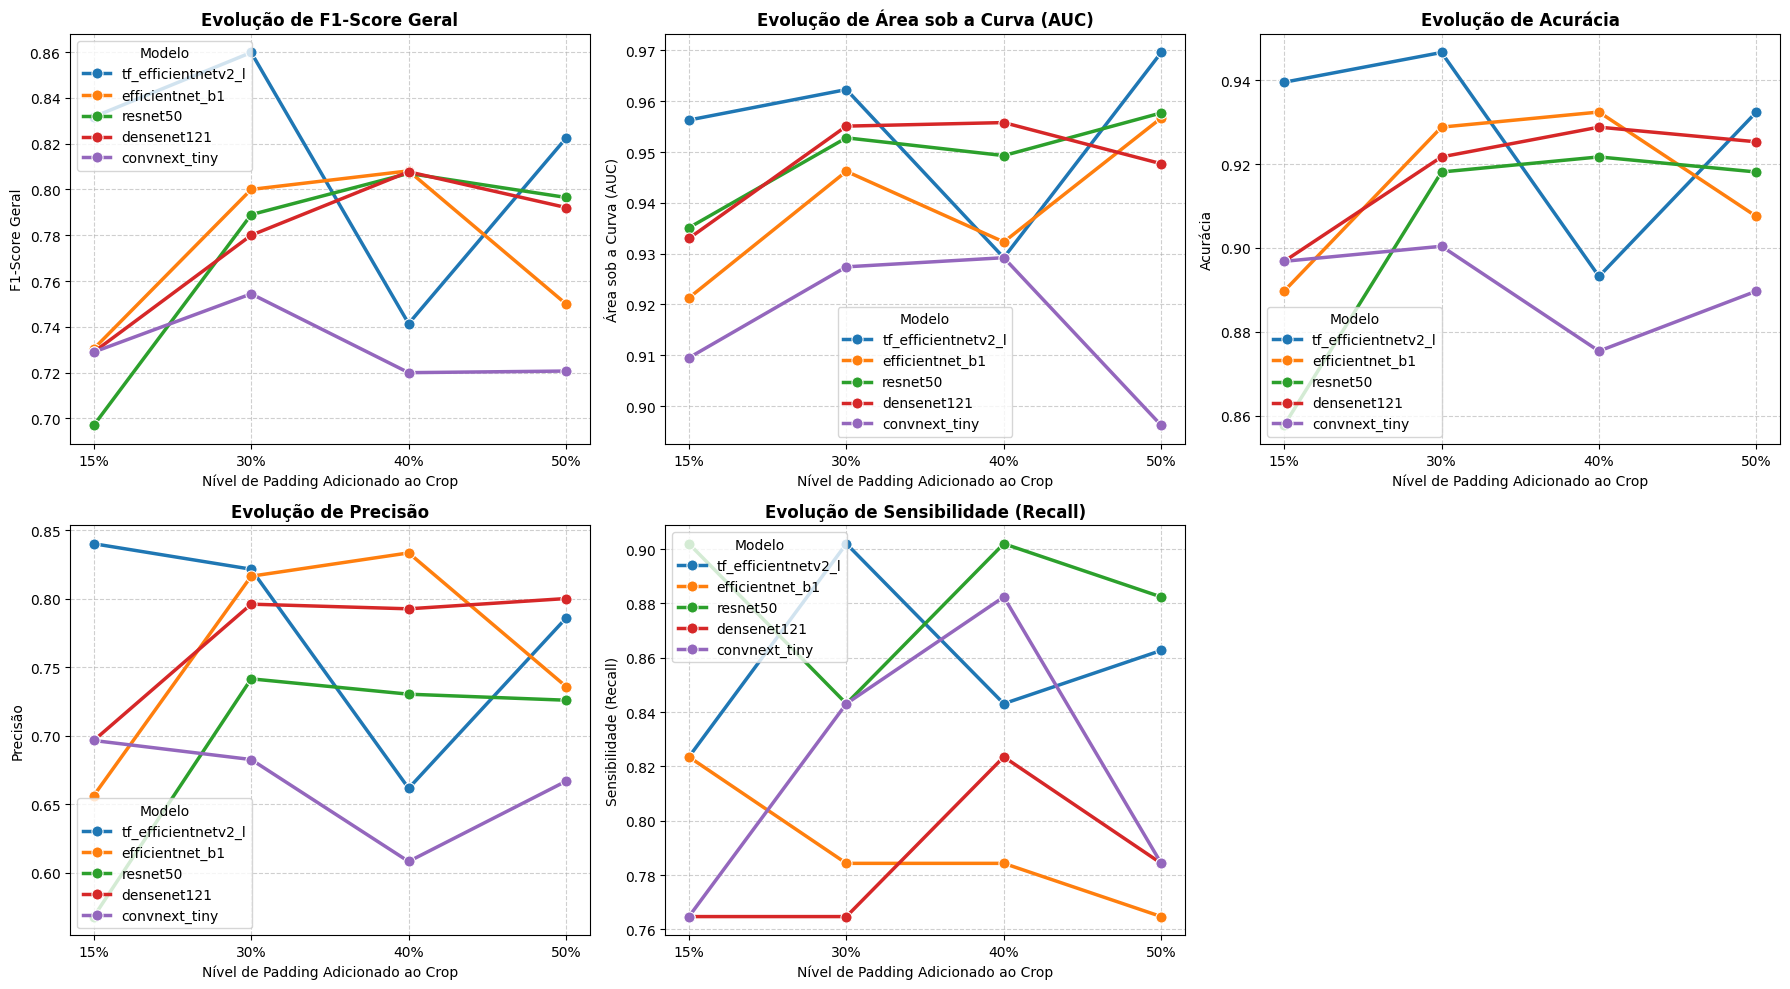

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Fallbacks de Caminho
WORKSPACE = Path.cwd()
if not (WORKSPACE / 'data').exists():
    WORKSPACE = WORKSPACE.parent.parent
FASE11_5_DIR = globals().get('FASE11_5_DIR', WORKSPACE / 'fases' / 'Fase11.5')
ARQUIVO_RESULTADOS = globals().get('ARQUIVO_RESULTADOS', FASE11_5_DIR / 'RESULTADOS_FASE11_5_SLIDING.csv')

try:
    df_plot = pd.read_csv(ARQUIVO_RESULTADOS)
    df_plot['Padding_Str'] = (df_plot['Padding'] * 100).astype(int).astype(str) + "%"

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    metricas = [
        ('F1_Score', 'F1-Score Geral'),
        ('AUC', 'Área sob a Curva (AUC)'),
        ('Acuracia', 'Acurácia'),
        ('Precision', 'Precisão'),
        ('Recall', 'Sensibilidade (Recall)')
    ]

    for idx, (col, title) in enumerate(metricas):
        if col in df_plot.columns:
            sns.lineplot(data=df_plot, x='Padding_Str', y=col, hue='Modelo', marker='o', linewidth=2.5, markersize=8, ax=axes[idx])
            axes[idx].set_title(f"Evolução de {title}", weight='bold')
            axes[idx].set_ylabel(title)
            axes[idx].set_xlabel("Nível de Padding Adicionado ao Crop")
            axes[idx].grid(True, linestyle='--', alpha=0.6)

    # Limpar subplots vazios remanescentes da grade 2x3
    for j in range(len(metricas), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig(str(FASE11_5_DIR / "Grafico_Evolucao_Padding_Sliding.png"), dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Erro ao plotar gráficos (você já treinou as redes?): {e}")

## Módulo 4: Explicabilidade Grad-CAM (Multi-Padding Sliding Window)
Gera o mapa de calor iterando sobre as combinações testadas...

In [ ]:
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import timm
from PIL import Image
from pathlib import Path
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

WORKSPACE = Path.cwd()
if not (WORKSPACE / 'data').exists():
    WORKSPACE = WORKSPACE.parent.parent

FASE11_5_DIR = globals().get('FASE11_5_DIR', WORKSPACE / 'fases' / 'Fase11.5')
DIR_ANOTACOES = globals().get('DIR_ANOTACOES', WORKSPACE / 'data' / 'Annotations')
DIR_IMAGENS_ORIGINAIS = globals().get('DIR_IMAGENS_ORIGINAIS', WORKSPACE / 'data' / 'images')
PASTA_MODELOS = globals().get('PASTA_MODELOS', FASE11_5_DIR / 'modelos_sliding_pad')
IMG_SIZE = globals().get('IMG_SIZE', 384)
DEVICE = globals().get('DEVICE', 'cuda' if torch.cuda.is_available() else 'cpu')
CLASSES = globals().get('CLASSES', ['benigno', 'maligno'])
PADDINGS = globals().get('PADDINGS', [0.15, 0.30, 0.40, 0.50])

DIR_GRADCAM_BASE = FASE11_5_DIR / 'HEATMAPS_FASE11_5_SLIDING'
DIR_GRADCAM_BASE.mkdir(parents=True, exist_ok=True)

if 'DATASETS_DIRS' not in globals():
    DATASETS_DIRS = {p: FASE11_5_DIR / f'dataset_fase9_physics_pad{int(p*100)}' for p in PADDINGS}

if 'MODELOS_PARA_TREINO' not in globals():
    MODELOS_PARA_TREINO = [
        {'name': 'tf_efficientnetv2_l'},
        {'name': 'efficientnet_b1'},
        {'name': 'resnet50'},
        {'name': 'densenet121'},
        {'name': 'convnext_tiny'},
    ]

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def obter_modelo_gradcam_sliding(model_name_original, pad_val):
    pad_str = str(int(pad_val * 100))
    nome_sanitizado = model_name_original.replace('/', '_').replace('-', '_')
    run_id = f"{nome_sanitizado}_sliding_pad{pad_str}"
    
    kwargs = {'pretrained': False, 'num_classes': 2}
    if 'swin' in model_name_original or 'vit' in model_name_original:
        kwargs['img_size'] = IMG_SIZE
        
    try:
        model = timm.create_model(model_name_original, drop_path_rate=0.0, **kwargs)
    except:
        model = timm.create_model(model_name_original, **kwargs)
        
    peso_path = PASTA_MODELOS / f'{run_id}.pth'
    if not peso_path.exists(): return None, None

    model.load_state_dict(torch.load(str(peso_path), map_location=DEVICE))
    model = model.eval().to(DEVICE)
    
    if 'densenet' in nome_sanitizado: target_layers = [model.features[-1]]
    elif 'resnet' in nome_sanitizado: target_layers = [model.layer4[-1]]
    elif 'convnext' in nome_sanitizado: target_layers = [model.stages[-1].blocks[-1]]
    elif 'efficientnet' in nome_sanitizado:
        try: target_layers = [model.conv_head]
        except: target_layers = [list(model.children())[-2]]
    else: target_layers = [list(model.children())[-2]]
        
    return model, target_layers

def rodar_gradcam_sliding(amostras_qtd=2):
    import warnings
    warnings.filterwarnings('ignore')
    
    for pad_val in PADDINGS:
        pad_str = str(int(pad_val * 100))
        dataset_teste_dir = DATASETS_DIRS.get(pad_val, FASE11_5_DIR / f'dataset_fase9_physics_pad{pad_str}') / 'teste'
        if not dataset_teste_dir.exists(): continue
            
        pasta_pad_out = DIR_GRADCAM_BASE / f"PAD_{pad_str}"
        pasta_pad_out.mkdir(parents=True, exist_ok=True)
        
        for config in MODELOS_PARA_TREINO:
            model_name_original = config['name']
            if 'swin' in model_name_original or 'vit' in model_name_original: continue
                
            model, target_layers = obter_modelo_gradcam_sliding(model_name_original, pad_val)
            if model is None: continue
                
            try: cam = GradCAM(model=model, target_layers=target_layers)
            except: continue

            for cls in CLASSES:
                pasta_alvo = dataset_teste_dir / cls
                arquivos = list(pasta_alvo.glob('*.*'))[:amostras_qtd]
                if not arquivos: continue
                    
                fig, axes = plt.subplots(len(arquivos), 2, figsize=(10, 4 * len(arquivos)))
                if len(arquivos) == 1: axes = [axes]
                
                for i, path_arq in enumerate(arquivos):
                    img_bgr = cv2.imread(str(path_arq))
                    img_rgb_base = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
                    img_rgb_384 = cv2.resize(img_rgb_base, (IMG_SIZE, IMG_SIZE))
                    img_norm = np.float32(img_rgb_384) / 255.0
                    
                    input_tensor = val_tf(Image.fromarray(img_rgb_base)).unsqueeze(0).to(DEVICE)
                    
                    with torch.no_grad():
                        out = model(input_tensor)
                        classe_pred = CLASSES[torch.argmax(out, dim=1).item()]
                        probs = torch.softmax(out, dim=1)[0, torch.argmax(out, dim=1).item()].item()
                    
                    targets = [ClassifierOutputTarget(torch.argmax(out, dim=1).item())]
                    heatmap = cam(input_tensor=input_tensor, targets=targets)[0, :]
                    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
                    
                    cam_image = show_cam_on_image(img_norm, heatmap_resized, use_rgb=True)
                    
                    axes[i][0].imshow(img_rgb_384)
                    axes[i][0].set_title(f"Real: {cls.upper()} | Sliding PAD {pad_str}%", fontsize=10)
                    axes[i][0].axis('off')
                    
                    axes[i][1].imshow(cam_image)
                    axes[i][1].set_title(f"Predito: {classe_pred.upper()} ({probs:.1%})", color='green' if classe_pred==cls else 'red', fontsize=10)
                    axes[i][1].axis('off')
                    
                plt.tight_layout()
                nome_sanitizado = model_name_original.replace('/', '_').replace('-', '_')
                plt.savefig(str(pasta_pad_out / f"Heatmap_Sliding_{nome_sanitizado}_{cls}.png"), dpi=150, bbox_inches='tight')
                plt.show()

# Descomente a linha abaixo para processar e plotar os grad-cams em massa
rodar_gradcam_sliding()